# Standard TVB simulation - Reduced Wong-Wang (ExcInh)
## Cerebellar-only network, same set-up as cMFM-TEST

**Goal of the notebook** is to provide a consistent test-bench for MAE computation.

- Same SC, number of regions, conduction speed, coupling, noise, monitors (Raw + BOLD, TR = 720 ms), stimulus, seed and simulation length as the cerebellar MF notebook.
- Only differences: node model = `ReducedWongWangExcInh` (TVB built-in, default parameters) and integration step `dt = 0.5 ms`.
- Output (raw time series + BOLD) saved to `.npz`.

*To replicate cMF-TVB paper results:*
- simlen = 14 minutes
- transient = 36 seconds
- dt = 0.1 ms
See parameters in Table 6, Lorenzi et al., 2025 NPJSBA
https://github.com/RobertaMLo/cMF-TVB$0

#### Import TVB and standard libraries

In [2]:

# ----------------------------------------------------------------------------
# 1a. Install dependencies (only if missing) ----------------------------------
# ----------------------------------------------------------------------------
try:
    import tvb.simulator.lab  # noqa: F401
    print('tvb-library already installed')
except ImportError:
    print('installing tvb-library ...')
    import subprocess, sys
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'tvb-library'], check=True)
    print('>>> If Colab asks to restart the runtime: restart and re-run this cell.')

try:
    import numba  # noqa: F401
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'numba'], check=True)

# ----------------------------------------------------------------------------
# 1b. Mount Google Drive ------------------------------------------------------
# ----------------------------------------------------------------------------
try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    IN_COLAB = True
except ImportError:
    IN_COLAB = False
    print('Not running in Colab: skipping Drive mount.')

# ----------------------------------------------------------------------------
# 1c. Imports -----------------------------------------------------------------
# ----------------------------------------------------------------------------
import os
import json
import time

import numpy as np
import numpy.random as rgn
import matplotlib.pyplot as plt

import scipy.special as sp_spec
from numba import jit

# TVB
import tvb
import tvb.simulator.lab as lab
from tvb.simulator.models.base import Model, numpy   # TVB's numpy, used in the model class body
from tvb.basic.neotraits.api import NArray, Range, Final, List

print('TVB   :', getattr(tvb, '__version__', 'n/a'))
print('numpy :', np.__version__)

installing tvb-library ...
>>> If Colab asks to restart the runtime: restart and re-run this cell.
Mounted at /content/drive


/usr/local/lib/python3.13/dist-packages/tvb/datatypes/surfaces.py:60: UserWarning: Geodesic distance module is unavailable; some functionality for surfaces will be unavailable.
  warnings.warn(msg)


TVB   : n/a
numpy : 2.1.3


#### Paths, simulation name and time settings

In [4]:
SUB_ID     = '103818'
model_name = 'WW'
sim_name   = 'cerebellum_'+model_name

day_folder   = '/content/drive/MyDrive/EITN_school_2026_MFM/Day5'
SC_pathname = os.path.join(day_folder, 'SC_dirCB_ONLYCRBL.zip') #'SC_CRBL_noDCN.zip'

output_folder_sim = day_folder

# ----------------------------------------------------------------------------
# Time settings (same as the MF notebook, except DT)
# ----------------------------------------------------------------------------
N_REGIONS = 27           # number of nodes in the cerebellar SC
SIM_LEN   = 120000.      # simulation length [ms]
DT        = 0.5          # integration step [ms]
CUT_TRANS = 2500.        # transient [ms], used to place the stimulus onset
MY_SEED   = 10           # random seed (noise + random initial history



print('SC file         :', SC_pathname, ' found' if os.path.exists(SC_pathname) else 'NOT FOUND')
print('Output folder   :', output_folder_sim)
print('Simulation name :', sim_name)

SC file         : /content/drive/MyDrive/EITN_school_2026_MFM/Day5/SC_dirCB_ONLYCRBL.zip  found
Output folder   : /content/drive/MyDrive/EITN_school_2026_MFM/Day5
Simulation name : cerebellum_WW


#### Set up the connectivity

In [5]:
CONDUCTION_SPEED = 3.0   # [mm/ms]

connection = lab.connectivity.Connectivity.from_file(SC_pathname)
connection.speed = np.array([CONDUCTION_SPEED])
connection.configure()   # SC not normalised (as in the MF notebook)

print('Number of regions :', connection.number_of_regions)
print('weights           :', connection.weights.shape,
      '| min %.4f  max %.4f' % (connection.weights.min(), connection.weights.max()))
print('tract_lengths     :', connection.tract_lengths.shape,
      '| max %.2f mm' % connection.tract_lengths.max())
print('speed             :', connection.speed, 'mm/ms')
print('max delay         : %.2f ms' % connection.delays.max())
assert connection.number_of_regions == N_REGIONS

2026-09-28 22:58:12,628 - WARNING - tvb.basic.readers - File 'average_orientations' not found in ZIP.
2026-09-28 22:58:12,632 - WARNING - tvb.basic.readers - File 'cortical' not found in ZIP.
2026-09-28 22:58:12,633 - WARNING - tvb.basic.readers - File 'hemispheres' not found in ZIP.
2026-09-28 22:58:12,635 - WARNING - tvb.basic.readers - File 'areas' not found in ZIP.
Number of regions : 27
weights           : (27, 27) | min 0.0000  max 0.5641
tract_lengths     : (27, 27) | max 106.12 mm
speed             : [3.] mm/ms
max delay         : 35.37 ms


#### Node model: Reduced Wong-Wang (ExcInh), TVB default parameters

In [6]:
model = lab.models.ReducedWongWangExcInh()

# State variables affected by the stimulus: S_e, S_i (same indices [0, 1] as the MF notebook)
STIM_STATE_VAR = [0, 1]
model.stvar = np.array(STIM_STATE_VAR)

print('Model             :', model.__class__.__name__)
print('State variables   :', model.state_variables)
print('Coupled variable  : %s (cvar = %s)' % (model.state_variables[int(model.cvar[0])], model.cvar))
print('Stimulated svars  :', model.stvar)
print('Initial state range (random, uniform):', dict(model.state_variable_range))

Model             : ReducedWongWangExcInh
State variables   : ['S_e', 'S_i']
Coupled variable  : S_e (cvar = [0])
Stimulated svars  : [0 1]
Initial state range (random, uniform): {'S_e': array([0., 1.]), 'S_i': array([0., 1.])}
  G        [2.]
  J_N      [0.15]
  J_i      [1.]
  w_p      [1.4]
  W_e      [1.]
  W_i      [0.7]
  I_o      [0.382]
  I_ext    [0.]
  lamda    [0.]
  a_e      [310.]
  b_e      [125.]
  d_e      [0.16]
  gamma_e  [0.000641]
  tau_e    [100.]
  a_i      [615.]
  b_i      [177.]
  d_i      [0.087]
  gamma_i  [0.001]
  tau_i    [10.]


#### Coupling, integrator, monitors, stimulus (same as the MF notebook)

In [7]:
# ----------------------------------------------------------------------------
# Coupling: linear, unit scaling on every cerebellar node
# ----------------------------------------------------------------------------
COUPLING_A = np.ones((N_REGIONS, 1))
COUPLING_B = 0.0

coupling = lab.coupling.Linear(a=COUPLING_A, b=np.array([COUPLING_B]))
print('Coupling   : Linear | a shape %s, unique values %s | b = %s'
      % (coupling.a.shape, np.unique(coupling.a), coupling.b))

# ----------------------------------------------------------------------------
# Stochastic integrator
# ----------------------------------------------------------------------------
NOISE_D   = 0.001            # noise standard deviation
NOISE_SIG = (NOISE_D ** 2) / 2
NOISE_TAU = 0.0              # 0 -> white noise

noise = lab.noise.Additive(nsig=np.array([NOISE_SIG]), ntau=NOISE_TAU)
noise.random_stream.seed(MY_SEED)   # also used for the random initial history

integrator = lab.integrators.HeunStochastic(noise=noise, dt=DT)
print('Integrator : HeunStochastic | dt = %s ms | nsig = %s | ntau = %s'
      % (integrator.dt, noise.nsig, noise.ntau))

# ----------------------------------------------------------------------------
# Monitors: raw time series + BOLD
# ----------------------------------------------------------------------------
BOLD_PERIOD = 720.0          # TR [ms], HCP protocol
BOLD_VOI    = [0]            # only S_e feeds the haemodynamic model

monitors = [
    lab.monitors.Raw(),
    lab.monitors.Bold(variables_of_interest=np.array(BOLD_VOI), period=BOLD_PERIOD),
]
print('\nMonitors (output order of the simulation):')
for i, m in enumerate(monitors):
    print('  [%d] %-8s period = %s' % (i, m.__class__.__name__, getattr(m, 'period', None)))

# ----------------------------------------------------------------------------
# Stimulus: kept in the pipeline but switched off (zero weights)
# ----------------------------------------------------------------------------
STIM_STRENGTH      = 0
STIM_REGION        = 1
STIM_DUR           = 50                                        # pulse duration, tau [ms]
INTERSTIM_INTERVAL = 1e9                                       # pulse period, T [ms]
STIM_ONSET         = CUT_TRANS + 0.5 * (SIM_LEN - CUT_TRANS)   # onset [ms]

stim_weights = np.zeros(N_REGIONS)
stim_weights[STIM_REGION] = STIM_STRENGTH

eqn_t = lab.equations.PulseTrain()
eqn_t.parameters['onset'] = np.array(STIM_ONSET)
eqn_t.parameters['tau']   = np.array(STIM_DUR)
eqn_t.parameters['T']     = np.array(INTERSTIM_INTERVAL)

stimulation = lab.patterns.StimuliRegion(temporal=eqn_t,
                                         connectivity=connection,
                                         weight=stim_weights)
print('\nStimulus   : PulseTrain onset = %.1f ms, tau = %.1f ms, T = %.3g ms | max weight = %.3g'
      % (STIM_ONSET, STIM_DUR, INTERSTIM_INTERVAL, stim_weights.max()))

Coupling   : Linear | a shape (27, 1), unique values [1.] | b = [0.]
Integrator : HeunStochastic | dt = 0.5 ms | nsig = [5.e-07] | ntau = 0.0

Monitors (output order of the simulation):
  [0] Raw      period = 0.0
  [1] Bold     period = 720.0

Stimulus   : PulseTrain onset = 61250.0 ms, tau = 50.0 ms, T = 1e+09 ms | max weight = 0


#### Set up the simulator

In [8]:
simulator = lab.simulator.Simulator(model=model,
                                    connectivity=connection,
                                    conduction_speed=CONDUCTION_SPEED,
                                    coupling=coupling,
                                    integrator=integrator,
                                    monitors=monitors,
                                    stimulus=stimulation)
simulator.configure()

print('Simulator configured')
print('  nodes            :', simulator.number_of_nodes)
print('  model            :', simulator.model.__class__.__name__)
print('  integrator       :', simulator.integrator.__class__.__name__, '| dt =', simulator.integrator.dt)
print('  conduction speed :', simulator.conduction_speed, 'mm/ms')
print('  coupling.a       :', simulator.coupling.a.shape, '| unique =', np.unique(simulator.coupling.a))
print('  BOLD period (TR) :', simulator.monitors[1].period, 'ms')
print('  history buffer   :', simulator.history.buffer.shape)

Simulator configured
  nodes            : 27
  model            : ReducedWongWangExcInh
  integrator       : HeunStochastic | dt = 0.5
  conduction speed : 3.0 mm/ms
  coupling.a       : (27, 1) | unique = [1.]
  BOLD period (TR) : 720.0 ms
  history buffer   : (72, 1, 27, 1)


## Run simulation

In [9]:
def run_sim_for_bold(simulator, time_len, raw_keep_every=1, print_every=20000):
    """Run the simulation, recording both the raw time series and the BOLD signal.

    Parameters
    ----------
    simulator : tvb.simulator.simulator.Simulator
        Already configured simulator.
    time_len : float
        Simulation length [ms].
    raw_keep_every : int
        Subsampling factor for the Raw monitor (1 = keep every sample).
    print_every : int
        Progress is printed every `print_every` integration steps.

    Returns
    -------
    tavg_time : list
        Sample times of the raw monitor [ms].
    tavg_data : ndarray
        Raw data, squeezed: (n_samples, n_state_variables, n_nodes).
    bold_time : list
        Sample times of the BOLD monitor [ms].
    bold_data : ndarray
        BOLD data, squeezed: (n_samples, n_nodes).
    """
    tavg_data, tavg_time = [], []
    bold_data, bold_time = [], []

    print('RUNNING SIMULATION -- length %.1f ms' % time_len)
    c_it = 0

    for tavg, bold in simulator(simulation_length=time_len):

        # --- raw monitor -----------------------------------------------------
        if tavg is not None:
            if c_it % raw_keep_every == 0:
                tavg_time.append(tavg[0])      # time [ms]
                tavg_data.append(tavg[1])      # (n_var, n_nodes, n_modes)

        # --- BOLD monitor ----------------------------------------------------
        if bold is not None:
            bold_time.append(bold[0])
            bold_data.append(bold[1])

        if c_it % print_every == 0:
            print('  step %8d   (t = %9.1f ms)   bold samples = %d'
                  % (c_it, c_it * simulator.integrator.dt, len(bold_time)))

        c_it += 1

    return tavg_time, np.squeeze(np.array(tavg_data)), bold_time, np.squeeze(np.array(bold_data))

In [10]:
RAW_KEEP_EVERY = 1       # 1 = keep every Raw sample (dt = 0.5 ms)

print('============== SIMULATION STARTS AT:', time.strftime("%H:%M:%S", time.localtime()))

tavgtime, tavgdata, boldtime, bolddata = run_sim_for_bold(
    simulator, SIM_LEN, raw_keep_every=RAW_KEEP_EVERY)

print('============== SIMULATION ENDS AT:  ', time.strftime("%H:%M:%S", time.localtime()))

print('\nOutput shapes')
print('  raw time series : ', np.shape(tavgdata), '  (samples, state variables, nodes)')
print('  BOLD            : ', np.shape(bolddata), '  (samples, nodes)')
if len(tavgtime) > 1:
    print('  raw sampling step: %.2f ms' % (tavgtime[1] - tavgtime[0]))

============== SIMULATION STARTS AT: 22:58:29
RUNNING SIMULATION -- length 120000.0 ms
  step        0   (t =       0.0 ms)   bold samples = 0
  step    20000   (t =   10000.0 ms)   bold samples = 13
  step    40000   (t =   20000.0 ms)   bold samples = 27
  step    60000   (t =   30000.0 ms)   bold samples = 41
  step    80000   (t =   40000.0 ms)   bold samples = 55
  step   100000   (t =   50000.0 ms)   bold samples = 69
  step   120000   (t =   60000.0 ms)   bold samples = 83
  step   140000   (t =   70000.0 ms)   bold samples = 97
  step   160000   (t =   80000.0 ms)   bold samples = 111
  step   180000   (t =   90000.0 ms)   bold samples = 125
  step   200000   (t =  100000.0 ms)   bold samples = 138
  step   220000   (t =  110000.0 ms)   bold samples = 152
============== SIMULATION ENDS AT:   22:59:55

Output shapes
  raw time series :  (240000, 2, 27)   (samples, state variables, nodes)
  BOLD            :  (166, 27)   (samples, nodes)
  raw sampling step: 0.50 ms


#### Quick check of the output

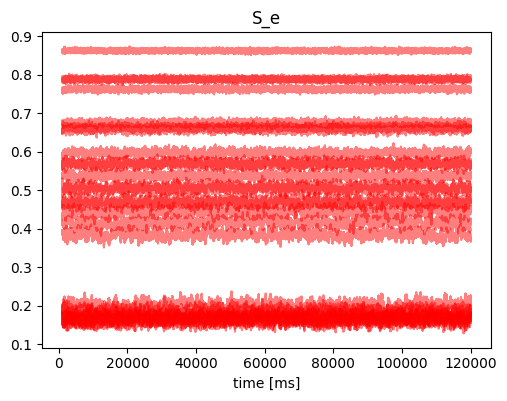

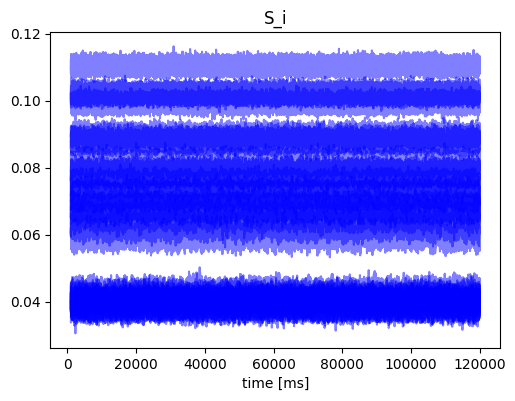

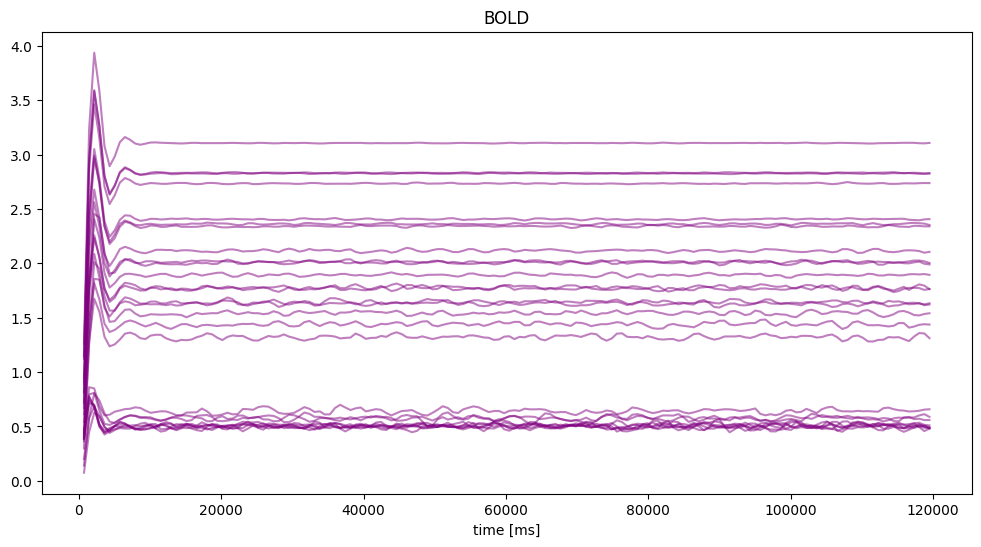

In [11]:
TTRANS_MS = 1000.                                   # discarded for plotting [ms]
ttrans = int(TTRANS_MS / (DT * RAW_KEEP_EVERY))     # in samples

t   = np.asarray(tavgtime)[ttrans:]
S_e = tavgdata[ttrans:, 0, :]
S_i = tavgdata[ttrans:, 1, :]

plt.figure(figsize=(5.8, 4.1))
plt.plot(t, S_e, color='red', alpha=0.5)
plt.title('S_e'); plt.xlabel('time [ms]')
plt.show()

plt.figure(figsize=(5.8, 4.1))
plt.plot(t, S_i, color='blue', alpha=0.5)
plt.title('S_i'); plt.xlabel('time [ms]')
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(boldtime, np.squeeze(bolddata), color='purple', alpha=0.5)
plt.title('BOLD'); plt.xlabel('time [ms]')
plt.show()

## Save output (.npz)

In [12]:
TR = simulator.monitors[1].period     # BOLD monitor period [ms]

out_file = os.path.join(output_folder_sim, sim_name + '.npz')
np.savez(out_file,
         timeseries_data=tavgdata,
         timeseries_time=tavgtime,
         bold_data=bolddata,
         bold_time=boldtime,
         dt=simulator.integrator.dt,
         TR=TR,
         cond_speed=simulator.conduction_speed,
         conn_name=os.path.basename(SC_pathname))

print('Saved: ', out_file)
print('dt =', simulator.integrator.dt, 'ms | TR =', TR, 'ms | cond_speed =', simulator.conduction_speed, 'mm/ms')

Saved:  /content/drive/MyDrive/EITN_school_2026_MFM/Day5/cerebellum_WW.npz
dt = 0.5 ms | TR = 720.0 ms | cond_speed = 3.0 mm/ms
